In [ ]:
# notebook to create MML activation function plot used in figure 1

In [21]:
import torch
import numpy as np
from typing import Union

import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"

In [12]:
#activation function from LEMBAS paper
def MML_activation(x: torch.Tensor, leak: Union[float, int]):
    """Returns the output of the Michaelis-Menten function

    Parameters
    ----------
    x : torch.Tensor
        a vector of input values
    leak : Union[float, int], optional
        parameter to tune extent of leaking, analogous to leaky ReLU

    Returns
    -------
    fx : torch.Tensor
        a vector of output values
    """
    fx = torch.nn.functional.leaky_relu(input = x, negative_slope = leak, inplace = False)
    shifted_x = 0.5 * (fx - 0.5)
    mask = torch.lt(shifted_x, 0.0)
    gated_x = fx + 10 * mask #prevents division by 0 issue on next line
    right_values = 0.5 + torch.div(shifted_x, gated_x)
    fx = mask * (fx - right_values) + right_values #-fx trick from relu
    return fx

In [20]:
#create input array of x values and use activation functions to get y values, then convert back to numpy arrays for plotting
x_vals = torch.tensor(np.linspace(-2, 2, 100)).to(device)
y_vals = MML_activation(x_vals, leak = 0.01)
x_vals = x_vals.cpu()
y_vals = y_vals.cpu()

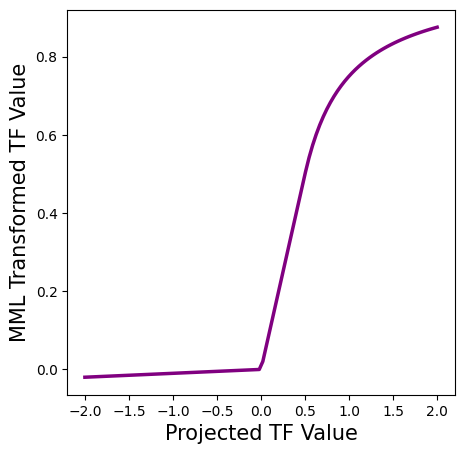

In [52]:
fig, ax = plt.subplots(ncols = 1, figsize = (5, 5))
sns.lineplot(x = x_vals, y = y_vals, ax = ax, linewidth = 2.5, color = '#800080')
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)
ax.set_xlabel('Projected TF Value', fontsize = 15)
ax.set_ylabel('MML Transformed TF Value', fontsize = 15)
plt.savefig(fname = './figures/MML_act_withAxesLabels', dpi = 300, bbox_inches = 'tight')

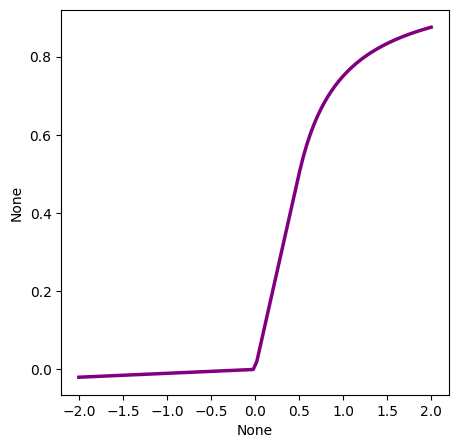

In [53]:
fig, ax = plt.subplots(ncols = 1, figsize = (5, 5))
sns.lineplot(x = x_vals, y = y_vals, ax = ax, linewidth = 2.5, color = '#800080')
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)
#ax.set_xlabel('Projected TF Value', fontsize = 15)
#ax.set_ylabel('MML Transformed TF Value', fontsize = 15)
plt.savefig(fname = './figures/MML_act_noAxesLabels', dpi = 300, bbox_inches = 'tight')